---------------------
FileFormat: 123
SystemType: 1
RecordingProgramName: b'IQUA'
RecordingProgramVersion: b'100'
SonarName: b'ScoutMkII_ros'
SonarType: 44
NoteString: b'Marine Sonic Technology Corp.'
ThisFileName: b'/home/user/logs/mk_ii/2025-09-24_12-50-35_0.xtf'
NavUnits: 3
NumberOfSonarChannels: 2
NumberOfBathymetryChannels: 0
NumberOfSnippetChannels: 0
NumberOfForwardLookArrays: 0
NumberOfEchoStrengthChannels: 0
NumberOfInterferometryChannels: 0
Reserved1: 0
Reserved2: 0
ReferencePointHeight: 0.0
ProjectionType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
SpheriodType: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]
NavigationLatency: 0
OriginY: 0.0
OriginX: 0.0
NavOffsetY: 0.0
NavOffsetX: 0.0
NavOffsetZ: 0.0
NavOffsetYaw: 0.0
MRUOffsetY: 0.0
MRUOffsetX: 0.0
MRUOffsetZ: 0.0
MRUOffsetYaw: 0.0
MRUOffsetPitch: 0.0
MRUOffsetRoll: 0.0
ChanInfo: [<pyxtf.xtf_ctypes.XTFChanInfo object at 0x7dff5ed95b50>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7dff5ed95bd0>, <pyxtf.xtf_ctypes.XTFChanInfo object at 0x7dff5ed95c

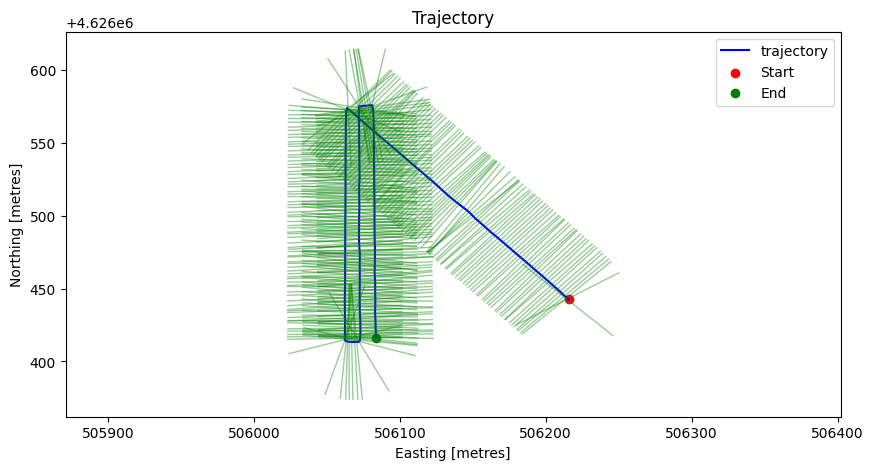

In [7]:
import physdnet.xtf_utils as xtf_utils
import matplotlib.pyplot as plt 

data_load = xtf_utils.load_xtf("/home/juan/Documents/IFROS/perception/HoP/HoP-SSS-Loop-Closure/data/2025-09-24_12-50-35_0.xtf")

swaths, trajectory, altitude, roll, pitch, yaw = xtf_utils.calculate_swath_positions(data_load)


_, ax = plt.subplots(figsize=(10,5))

# Plot trajectory
ax.plot(trajectory[:,0], trajectory[:,1], color="blue", label="trajectory")

# Plot ping lines 
step = 50
#theshold = 
#for i in range(4520, swaths.shape[0], step):
for i in range(40, swaths.shape[0], step):
    start_point = swaths[i, 0, :]      
    end_point = swaths[i, -1, :]       
    
    x_vals = [start_point[0], end_point[0]]
    y_vals = [start_point[1], end_point[1]]
    
    if i == 0:
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1, label=f"swaths with step={step}")
    else:    
        ax.plot(x_vals, y_vals, color='green', linestyle='-', alpha=0.4, linewidth=1)

ax.axis("equal")
ax.set_title("Trajectory")
ax.set_xlabel("Easting [metres]")
ax.set_ylabel("Northing [metres]")
ax.axis("equal")
ax.scatter([trajectory[0,0]], [trajectory[0,1]], label="Start", c="red")
ax.scatter([trajectory[-1,0]], [trajectory[-1,1]], label="End", c="green")
ax.legend()

plt.show()


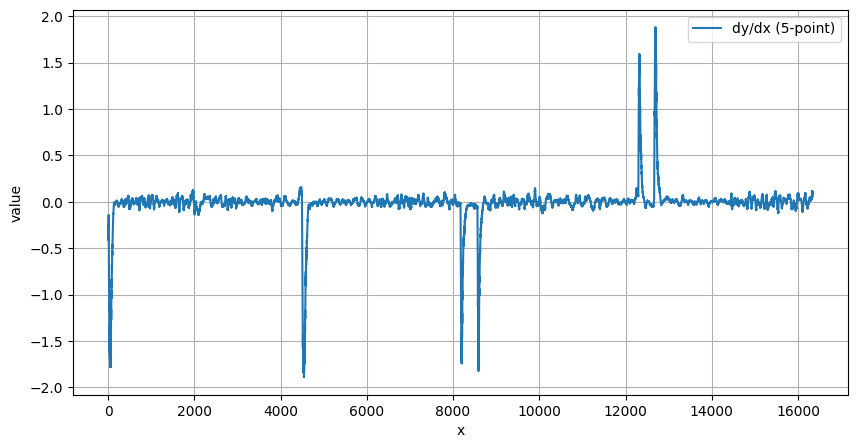

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def numerical_derivative_5point(x, y):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    if len(x) != len(y):
        raise ValueError("x and y must have the same length")
    if len(x) < 5:
        raise ValueError("Need at least 5 points")

    h = x[1] - x[0]
    if not np.allclose(np.diff(x), h):
        raise ValueError("This 5-point formula assumes equally spaced x values")

    dydx = np.empty_like(y)

    # Forward 5-point formula for first two points
    dydx[0] = (-25*y[0] + 48*y[1] - 36*y[2] + 16*y[3] - 3*y[4]) / (12*h)
    dydx[1] = (-3*y[0] - 10*y[1] + 18*y[2] - 6*y[3] + y[4]) / (12*h)

    # Central 5-point formula for interior points
    for i in range(2, len(y) - 2):
        dydx[i] = (y[i-2] - 8*y[i-1] + 8*y[i+1] - y[i+2]) / (12*h)

    # Backward 5-point formula for last two points
    dydx[-2] = (-y[-5] + 6*y[-4] - 18*y[-3] + 10*y[-2] + 3*y[-1]) / (12*h)
    dydx[-1] = (3*y[-5] - 16*y[-4] + 36*y[-3] - 48*y[-2] + 25*y[-1]) / (12*h)

    return dydx

dy = numerical_derivative_5point(np.arange(len(np.unwrap(yaw)*180/np.pi)), np.unwrap(yaw)*180/np.pi)

_, ax = plt.subplots(figsize=(10,5))
ax.plot(np.arange(len(np.unwrap(yaw)*180/np.pi)), dy, label="dy/dx (5-point)")
ax.set_xlabel("x")
ax.set_ylabel("value")
ax.legend()
plt.grid(True)
plt.show()


In [13]:
Ids = np.where(np.abs(dy)>0.25)[0]
print("Indices where dy/dx > 0.5:", Ids)

new_index = range(0, swaths.shape[0],1)
new_index = np.delete(new_index,Ids)


Indices where dy/dx > 0.5: [    0     1     2     3     4     5     6    14    15    16    17    18
    19    20    21    22    23    24    25    26    27    28    29    30
    31    32    33    34    35    36    37    38    39    40    41    42
    43    44    45    46    47    48    49    50    51    52    53    54
    55    56    57    58    59    60    61    62    63    64    65    66
    67    68    69    70    71    72    73    74    75    76    77    78
    79    80    81    82    83    84    85    86    87    88    89    90
    91    92    93    94    95    96    97    98    99   100   101   102
   103   104   105   106   107   108   109   110   111  4499  4500  4501
  4502  4503  4504  4505  4506  4507  4508  4509  4510  4511  4512  4513
  4514  4515  4516  4517  4518  4519  4520  4521  4522  4523  4524  4525
  4526  4527  4528  4529  4530  4531  4532  4533  4534  4535  4536  4537
  4538  4539  4540  4541  4542  4543  4544  4545  4546  4547  4548  4549
  4550  4551  4552  4553